# Waze User Churn - 03. Modeling and Evaluation

**Project Goal:** To build a machine learning model that predicts user churn risk and supports business-facing retention decisions.

**Notebook 03 Goal:** In this notebook, I will build, compare, and evaluate several churn prediction models using a business-aware modeling framework. The focus is not only on predicting which users are likely to churn, but also on selecting a model and decision threshold that balance churn detection with the cost of unnecessary interventions.

This notebook will cover:

- Preparing the modeling dataset and recreating engagement-based features;
- Splitting the data into training, validation, and test sets;
- Training and comparing multiple machine learning models;
- Evaluating model performance using Precision, Recall, F1-score, F2-score, ROC-AUC, and PR-AUC;
- Selecting a model based on a balanced churn-oriented metric rather than accuracy alone;
- Tuning the decision threshold using validation performance;
- Applying cost-sensitive evaluation to account for false positives and false negatives;
- Calibrating predicted probabilities so they can be used as churn risk scores;
- Evaluating the final model on the test set;
- Saving the final calibrated model, selected threshold, metadata, and prediction outputs for the next notebook.

## 1. Business Evaluation Strategy

In churn prediction, recall is important because missing actual churners means losing the opportunity to intervene. However, optimizing recall alone can create too many false positives.

A false positive means the model flags a retained user as likely to churn. In a real retention workflow, this can lead to:

- Unnecessary campaign cost;
- Irrelevant notifications or offers;
- User annoyance;
- Lower trust from business stakeholders.

Therefore, the final model should not simply maximize recall. It should capture many churners while keeping false alarms manageable.

For this notebook, I will evaluate models using:

- **Precision**: among users predicted as churned, how many actually churned;
- **Recall**: among actual churned users, how many were detected;
- **F1-score**: harmonic mean of precision and recall;
- **F2-score**: recall-weighted F-score, useful when recall is more important than precision;
- **ROC-AUC**: overall ranking quality across both classes;
- **PR-AUC / Average Precision**: especially useful for imbalanced classification;
- **Cost-sensitive evaluation**: a simple business proxy that penalizes false negatives more than false positives.

## 2. Import Libraries and Load Data

In [1]:
# import libraries for data manipulation and visualization
import os
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn utilities
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    brier_score_loss,
    make_scorer
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# xgboost
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# visualization settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [2]:
# load the cleaned data
df = pd.read_csv("../data/processed/waze_clean.csv")

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (14299, 19)


,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,is_high_sessions,is_high_drives,is_high_total_sessions,is_high_driven_km_drives,is_high_duration_minutes_drives,is_high_total_navigations_fav1,is_high_total_navigations_fav2
0,retained,283,226,296.7483,2276,208,0,2628.8451,1985.7751,28,19,Android,1,1,0,0,0,0,0
1,retained,133,107,326.8966,1225,19,64,13715.9206,3160.4729,13,11,iPhone,0,0,0,1,0,0,0
2,retained,114,95,135.5229,2651,0,0,3059.1488,1610.7359,14,8,Android,0,0,0,0,0,0,0
3,retained,49,40,67.5892,15,322,7,913.5911,587.1965,7,3,iPhone,0,0,0,0,0,0,0
4,retained,84,68,168.2470,1562,166,5,3950.2020,1219.5559,27,18,Android,0,0,0,0,0,0,0


In [3]:
# quick check
print("Target distribution:")
display(df["label"].value_counts(normalize=False).to_frame("count"))

print("\nTarget distribution (%):")
display((df["label"].value_counts(normalize=True) * 100).to_frame("pct"))

Target distribution:


,count
label,
retained,11763
churned,2536



Target distribution (%):


,pct
label,
retained,82.2645
churned,17.7355


## 3. Feature Engineering Setup

The feature engineering logic is defined as a reusable function so that the same transformations can be used consistently in training, validation, testing, and future inference.

The engineered features are based on the Notebook 01 EDA insights:

- Usage consistency: `activity_days`, `driving_days`;
- Tenure/lifecycle: `n_days_after_onboarding`;
- Driving intensity: kilometers or minutes per drive/day;
- Waze-specific stickiness: favorite navigation behavior.

In [4]:
def safe_divide(numerator, denominator):
    """Safely divide two pandas Series and replace inf/NaN with 0."""
    result = numerator / denominator.replace(0, np.nan)
    result = result.replace([np.inf, -np.inf], np.nan).fillna(0)
    return result


def add_waze_features(X):
    """Create Waze-specific engineered features.

    This function expects the raw cleaned Waze dataframe without the target column.
    It returns a dataframe with original features plus engineered features.
    """
    X = X.copy()

    # engagement normalized by tenure
    X["sessions_per_day_after_onboarding"] = safe_divide(
        X["sessions"], X["n_days_after_onboarding"]
    )
    X["total_sessions_per_day_after_onboarding"] = safe_divide(
        X["total_sessions"], X["n_days_after_onboarding"]
    )

    # usage frequency and intensity
    X["drives_per_activity_day"] = safe_divide(X["drives"], X["activity_days"])
    X["drives_per_driving_day"] = safe_divide(X["drives"], X["driving_days"])
    X["km_per_drive"] = safe_divide(X["driven_km_drives"], X["drives"])
    X["minutes_per_drive"] = safe_divide(X["duration_minutes_drives"], X["drives"])
    X["km_per_driving_day"] = safe_divide(X["driven_km_drives"], X["driving_days"])
    X["minutes_per_driving_day"] = safe_divide(X["duration_minutes_drives"], X["driving_days"])

    # recent activity share
    X["percent_sessions_in_last_month"] = safe_divide(
        X["sessions"], X["total_sessions"]
    )

    # favorite navigation behavior
    X["total_favorite_navigations"] = (
        X["total_navigations_fav1"] + X["total_navigations_fav2"]
    )
    X["has_favorite_navigation"] = (X["total_favorite_navigations"] > 0).astype(int)
    X["favorite_navigations_per_session"] = safe_divide(
        X["total_favorite_navigations"], X["total_sessions"]
    )

    return X

### 3.1. Optional Percentile Capping Transformer

Notebook 01 kept extreme usage values because they may represent meaningful Waze behavior. However, some algorithms such as Logistic Regression and SVM can be sensitive to highly skewed variables.

To make outlier handling a controlled modeling experiment, I define a custom transformer that learns percentile caps from the **training data only**. This prevents leakage from validation or test data.

In this notebook, capping is not treated as a cleaning rule. It is only a model-specific preprocessing option.

In [5]:
class PercentileCapper(BaseEstimator, TransformerMixin):
    """Clip numeric columns at learned lower and upper percentiles.

    The caps are learned only from the training data during fit().
    """

    def __init__(self, lower=0.00, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.numeric_cols_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        self.lower_bounds_ = X_df[self.numeric_cols_].quantile(self.lower)
        self.upper_bounds_ = X_df[self.numeric_cols_].quantile(self.upper)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in self.numeric_cols_:
            if col in X_df.columns:
                X_df[col] = X_df[col].clip(
                    lower=self.lower_bounds_[col],
                    upper=self.upper_bounds_[col]
                )
        return X_df

## 4. Define Target, Features, and Train/Validation/Test Split

The data will be split into:

- **Train set (60%)**: used for model fitting and cross-validation;
- **Validation set (20%)**: used for model comparison, calibration, and threshold tuning;
- **Test set (20%)**: used only once for final evaluation.

This separation is important because threshold tuning and calibration should not be performed on the final test set.

In [6]:
# define feature matrix and target
X = df.drop(columns=["label", "ID"], errors="ignore")
y = df["label"].map({"retained": 0, "churned": 1})

# first split: train+validation vs test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,  # 0.25 * 0.80 = 0.20
    random_state=42,
    stratify=y_train_val
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

print("\nTarget rate by split:")
split_rates = pd.DataFrame({
    "train": y_train.value_counts(normalize=True),
    "validation": y_val.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True)
}).T
display(split_rates.rename(columns={0: "retained", 1: "churned"}))

Train shape: (8579, 18)
Validation shape: (2860, 18)
Test shape: (2860, 18)

Target rate by split:


label,retained,churned
train,0.8226,0.1774
validation,0.8227,0.1773
test,0.8227,0.1773


## 5. Build Preprocessing Pipelines

I will use model-specific preprocessing:

1. **Standard scaled preprocessing** for Logistic Regression, SVM, and Neural-Network-like models.
2. **Robust scaled + percentile capped preprocessing** as an alternative for scale-sensitive models.
3. **Tree preprocessing** for Decision Tree, Random Forest, and XGBoost, where numeric scaling is not required.

All pipelines include the same feature engineering step, so model comparison remains consistent.

In [7]:
# create a sample engineered dataframe to identify columns after feature engineering
X_train_fe_sample = add_waze_features(X_train)

categorical_cols = ["device"] if "device" in X_train_fe_sample.columns else []
numeric_cols = [col for col in X_train_fe_sample.columns if col not in categorical_cols]

print(f"Number of numeric features after engineering: {len(numeric_cols)}")
print(f"Categorical features: {categorical_cols}")

Number of numeric features after engineering: 29
Categorical features: ['device']


In [8]:
def build_preprocessor(scaler_type="standard"):
    """Create a ColumnTransformer for numeric and categorical features."""

    if scaler_type == "standard":
        numeric_transformer = StandardScaler()
    elif scaler_type == "robust":
        numeric_transformer = RobustScaler()
    elif scaler_type == "none":
        numeric_transformer = "passthrough"
    else:
        raise ValueError("scaler_type must be one of: 'standard', 'robust', 'none'")

    categorical_transformer = OneHotEncoder(handle_unknown="ignore", drop="first")

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    return preprocessor


def make_pipeline(model, scaler_type="standard", use_capping=False):
    """Create a full modeling pipeline with feature engineering and preprocessing."""

    steps = [
        ("feature_engineering", FunctionTransformer(add_waze_features, validate=False))
    ]

    if use_capping:
        steps.append(("percentile_capping", PercentileCapper(lower=0.00, upper=0.99)))

    steps.extend([
        ("preprocessor", build_preprocessor(scaler_type=scaler_type)),
        ("model", model)
    ])

    return Pipeline(steps)

## 6. Define Models and Hyperparameter Grids

The model set includes simple baselines and stronger nonlinear models:

- `DummyClassifier`: baseline that ignores features;
- `LogisticRegression`: interpretable linear baseline;
- `DecisionTree`: simple nonlinear tree baseline;
- `RandomForest`: stronger ensemble tree model;
- `XGBoost`: gradient boosting model suitable for tabular data;
- `SVM`: strong margin-based model for nonlinear classification.

Class imbalance is handled through `class_weight="balanced"` for compatible models and `scale_pos_weight` for XGBoost.

In [9]:
# class imbalance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

# define scoring metrics
f2_scorer = make_scorer(fbeta_score, beta=2)

scoring_metrics = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": f2_scorer,
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scale_pos_weight for XGBoost: 4.64


In [10]:
models_with_params = {
    "DummyClassifier": {
        "pipeline": make_pipeline(
            DummyClassifier(strategy="prior", random_state=42),
            scaler_type="none",
            use_capping=False
        ),
        "params": {}
    },

    "LogisticRegression": {
        "pipeline": make_pipeline(
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
            scaler_type="standard",
            use_capping=False
        ),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs"]
        }
    },

    "LogisticRegression_RobustCapped": {
        "pipeline": make_pipeline(
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
            scaler_type="robust",
            use_capping=True
        ),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs"]
        }
    },

    "DecisionTree": {
        "pipeline": make_pipeline(
            DecisionTreeClassifier(class_weight="balanced", random_state=42),
            scaler_type="none",
            use_capping=False
        ),
        "params": {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_leaf": [20, 50, 100],
            "model__min_samples_split": [50, 100, 200]
        }
    },

    "RandomForest": {
        "pipeline": make_pipeline(
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ),
            scaler_type="none",
            use_capping=False
        ),
        "params": {
            "model__max_depth": [5, 8, None],
            "model__min_samples_leaf": [10, 30, 50],
            "model__max_features": ["sqrt", 0.5]
        }
    },

    "XGBoost": {
        "pipeline": make_pipeline(
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
                scale_pos_weight=scale_pos_weight
            ),
            scaler_type="none",
            use_capping=False
        ),
        "params": {
            "model__n_estimators": [150, 300],
            "model__max_depth": [3, 4],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
            "model__reg_lambda": [1, 5]
        }
    },

    "SVM": {
        "pipeline": make_pipeline(
            SVC(class_weight="balanced", probability=True, random_state=42),
            scaler_type="standard",
            use_capping=False
        ),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["rbf"],
            "model__gamma": ["scale", 0.01, 0.001]
        }
    },

    "SVM_RobustCapped": {
        "pipeline": make_pipeline(
            SVC(class_weight="balanced", probability=True, random_state=42),
            scaler_type="robust",
            use_capping=True
        ),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["rbf"],
            "model__gamma": ["scale", 0.01, 0.001]
        }
    }
}

## 7. Train Models with Cross-Validation

I will use `GridSearchCV` with multiple scoring metrics and set `refit="f2"`.

F2-score is chosen because it still prioritizes recall, but it penalizes extremely low precision more than recall-only optimization. This directly addresses the business issue of creating too many false positives.

In [11]:
cv_results = []
best_estimators = {}

for model_name, config in models_with_params.items():
    print(f"\n========== Training {model_name} ==========")

    grid_search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring=scoring_metrics,
        refit="f2",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    best_estimators[model_name] = grid_search.best_estimator_

    best_idx = grid_search.best_index_
    result_row = {
        "model": model_name,
        "best_params": grid_search.best_params_,
        "cv_precision": grid_search.cv_results_["mean_test_precision"][best_idx],
        "cv_recall": grid_search.cv_results_["mean_test_recall"][best_idx],
        "cv_f1": grid_search.cv_results_["mean_test_f1"][best_idx],
        "cv_f2": grid_search.cv_results_["mean_test_f2"][best_idx],
        "cv_roc_auc": grid_search.cv_results_["mean_test_roc_auc"][best_idx],
        "cv_pr_auc": grid_search.cv_results_["mean_test_average_precision"][best_idx]
    }
    cv_results.append(result_row)

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_f2", ascending=False)
display(cv_results_df)


========== Training DummyClassifier ==========
Fitting 5 folds for each of 1 candidates, totalling 5 fits

========== Training LogisticRegression ==========
Fitting 5 folds for each of 4 candidates, totalling 20 fits

========== Training LogisticRegression_RobustCapped ==========
Fitting 5 folds for each of 4 candidates, totalling 20 fits

========== Training DecisionTree ==========
Fitting 5 folds for each of 36 candidates, totalling 180 fits

========== Training RandomForest ==========
Fitting 5 folds for each of 18 candidates, totalling 90 fits

========== Training XGBoost ==========
Fitting 5 folds for each of 64 candidates, totalling 320 fits

========== Training SVM ==========
Fitting 5 folds for each of 9 candidates, totalling 45 fits

========== Training SVM_RobustCapped ==========
Fitting 5 folds for each of 9 candidates, totalling 45 fits


,model,best_params,cv_precision,cv_recall,cv_f1,cv_f2,cv_roc_auc,cv_pr_auc
6,SVM,"{'model__C': 0.1, 'model__gamma': 0.001, 'mode...",0.3118,0.7326,0.4373,0.5767,0.7512,0.3816
7,SVM_RobustCapped,"{'model__C': 10, 'model__gamma': 0.001, 'model...",0.3076,0.7339,0.4334,0.5745,0.7480,0.3766
1,LogisticRegression,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.3186,0.7161,0.4409,0.5730,0.7529,0.3949
2,LogisticRegression_RobustCapped,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.3203,0.7115,0.4416,0.5716,0.7534,0.3880
5,XGBoost,"{'model__colsample_bytree': 1.0, 'model__learn...",0.3228,0.6964,0.4410,0.5654,0.7432,0.3813
3,DecisionTree,"{'model__max_depth': 3, 'model__min_samples_le...",0.3028,0.7155,0.4250,0.5614,0.7308,0.3393
4,RandomForest,"{'model__max_depth': 5, 'model__max_features':...",0.3289,0.6695,0.4410,0.5545,0.7473,0.3879
0,DummyClassifier,{},0.0000,0.0000,0.0000,0.0000,0.5000,0.1774


**Cross-validation result interpretation**

The cross-validation results show that several models perform very closely in terms of F2-score. SVM has the highest mean CV F2-score, followed closely by SVM with robust capping and Logistic Regression variants. The differences are relatively small, which suggests that the dataset contains strong behavioral signals that can be captured by both linear and nonlinear models.

Although SVM ranks highest in cross-validation F2, model selection is not finalized at this stage. The best estimator from each model family will be evaluated again on the validation set using the default threshold. This gives an additional holdout-based comparison before probability calibration and threshold tuning.

## 8. Validation Set Evaluation

Cross-validation gives a stable estimate during training, but I will compare the best version of each model on the validation set before selecting the final candidate.

This validation evaluation uses the default 0.5 threshold first. Later, I will tune the threshold explicitly.

In [12]:
def get_positive_proba(model, X):
    """Return predicted probability for the positive class if available."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        # min-max fallback for models without predict_proba
        return (scores - scores.min()) / (scores.max() - scores.min())
    raise ValueError("Model does not support probability or decision scores.")


def evaluate_binary_classifier(y_true, y_proba, threshold=0.5):
    """Return common binary classification metrics."""
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }

In [13]:
validation_results = []

for model_name, model in best_estimators.items():
    y_val_proba = get_positive_proba(model, X_val)
    metrics = evaluate_binary_classifier(y_val, y_val_proba, threshold=0.5)
    metrics["model"] = model_name
    validation_results.append(metrics)

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values(["f2", "pr_auc"], ascending=False)
    .reset_index(drop=True)
)

display(validation_results_df)

,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,model
0,0.5000,0.6923,0.3297,0.7120,0.4507,0.5780,0.7621,0.3750,LogisticRegression_RobustCapped
1,0.5000,0.6857,0.3241,0.7120,0.4454,0.5745,0.7646,0.3758,LogisticRegression
2,0.5000,0.6972,0.3299,0.6864,0.4456,0.5644,0.7590,0.3839,XGBoost
3,0.5000,0.7087,0.3367,0.6627,0.4465,0.5552,0.7607,0.3839,RandomForest
4,0.5000,0.7101,0.3357,0.6489,0.4425,0.5469,0.7401,0.3381,DecisionTree
5,0.5000,0.8136,0.3839,0.0848,0.1389,0.1005,0.7549,0.3652,SVM
6,0.5000,0.8220,0.4615,0.0237,0.0450,0.0292,0.7588,0.3842,SVM_RobustCapped
7,0.5000,0.8227,0.0000,0.0000,0.0000,0.0000,0.5000,0.1773,DummyClassifier


**Validation result interpretation**

On the validation set, `LogisticRegression_RobustCapped` achieves the highest F2-score at the default 0.5 threshold. Its recall remains high while precision is slightly better than the more aggressive SVM models. This makes it a stronger candidate for a business-facing churn model, because it balances churn detection with false-positive control.

Tree-based models such as Random Forest and XGBoost also perform competitively, but they do not improve F2 enough to justify selecting them as the final candidate in this run. Since Logistic Regression is also easier to interpret and calibrate, it is a reasonable final candidate for threshold tuning.

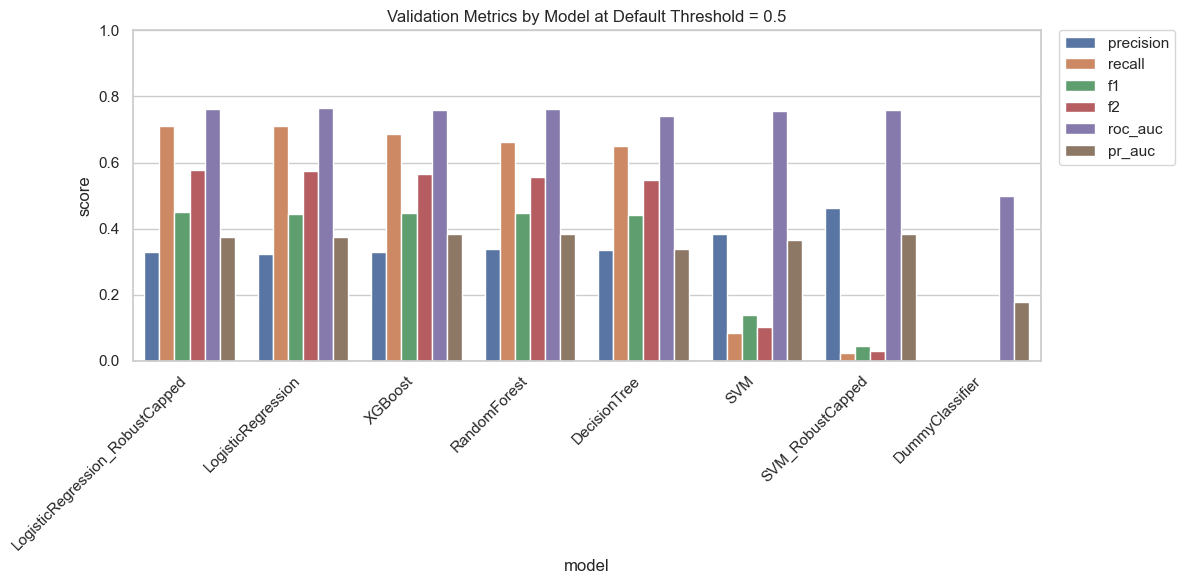

In [14]:
# visualize validation comparison
metric_cols = ["precision", "recall", "f1", "f2", "roc_auc", "pr_auc"]

plot_df = validation_results_df.melt(
    id_vars="model",
    value_vars=metric_cols,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.title("Validation Metrics by Model at Default Threshold = 0.5")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout() 
plt.show()

### 8.1. Select Candidate Model Before Threshold Tuning

Before tuning the decision threshold, I first select one candidate model from the validation results.

At this stage, all models are still evaluated using the default classification threshold of 0.5. Therefore, this step is not the final business decision rule yet. Instead, it identifies the most suitable model to carry forward into the next stages of the workflow.

The candidate model is selected based mainly on validation F2-score, while also considering PR-AUC, precision-recall balance, model simplicity, and interpretability.

After the candidate model is selected, it will be used for:

- Probability calibration;
- Threshold tuning;
- Cost-sensitive evaluation;
- Final test-set evaluation.

In [15]:
# select candidate model by validation F2, then PR-AUC
candidate_row = validation_results_df.sort_values(
    ["f2", "pr_auc"],
    ascending=False
).iloc[0]

candidate_model_name = candidate_row["model"]
candidate_model = best_estimators[candidate_model_name]

print(f"Selected candidate model: {candidate_model_name}")
display(candidate_row.to_frame().T)

Selected candidate model: LogisticRegression_RobustCapped


,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,model
0,0.5000,0.6923,0.3297,0.7120,0.4507,0.5780,0.7621,0.3750,LogisticRegression_RobustCapped


**Candidate model decision**

The selected candidate model is `LogisticRegression_RobustCapped`. This is a useful result from a business perspective because the model is simpler and more interpretable than SVM or XGBoost, while still achieving the best validation F2-score.

This also suggests that churn in this dataset is strongly driven by relatively stable behavioral patterns such as activity frequency, driving frequency, tenure, and normalized usage intensity. A complex nonlinear model is not always necessary when engineered behavioral features already capture the main churn signals.

## 9. Probability Calibration

After selecting the candidate model, the next step is to calibrate its predicted probabilities.

This is important because the model output will later be used not only for binary classification, but also as a **churn risk score**. For example, if the model assigns a user a churn probability of 0.40, that score should approximately reflect the observed churn risk among similar users.

Calibration adjusts the predicted probabilities so that they better match observed churn frequencies. This is especially important before threshold tuning and risk tiering, because poorly calibrated probabilities can lead to misleading risk groups or inappropriate business decisions.

In this notebook, I will calibrate the selected candidate model using the validation set. The test set remains untouched and will only be used later for final evaluation.

In [16]:
# probability before calibration
y_val_proba_before = get_positive_proba(candidate_model, X_val)
brier_before = brier_score_loss(y_val, y_val_proba_before)

# calibrate the already fitted candidate model using validation set
calibrated_model = CalibratedClassifierCV(
    estimator=candidate_model,
    method="sigmoid",
    cv="prefit"
)
calibrated_model.fit(X_val, y_val)

# probability after calibration
y_val_proba_after = calibrated_model.predict_proba(X_val)[:, 1]
brier_after = brier_score_loss(y_val, y_val_proba_after)

print(f"Brier score before calibration: {brier_before:.4f}")
print(f"Brier score after calibration:  {brier_after:.4f}")

Brier score before calibration: 0.2016
Brier score after calibration:  0.1279


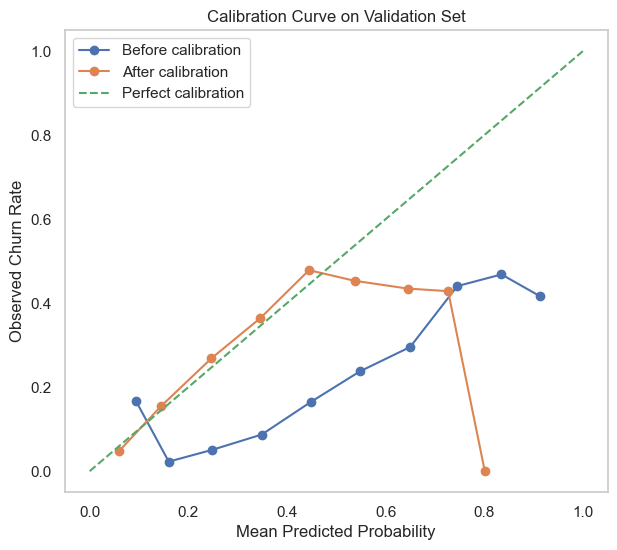

In [17]:
# plot calibration curve
prob_true_before, prob_pred_before = calibration_curve(y_val, y_val_proba_before, n_bins=10)
prob_true_after, prob_pred_after = calibration_curve(y_val, y_val_proba_after, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred_before, prob_true_before, marker="o", label="Before calibration")
plt.plot(prob_pred_after, prob_true_after, marker="o", label="After calibration")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Curve on Validation Set")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.legend()
plt.grid(False)
plt.show()

**Calibration result interpretation**

The Brier score improved from **0.2016** before calibration to **0.1279** after calibration. Since a lower Brier score indicates better probability accuracy, this suggests that the calibrated probabilities are better aligned with the observed churn outcomes.

The calibration curve also shows a clear improvement. Before calibration, the model was generally **overconfident (over-estimating the churn risk)** across much of the probability range: the predicted probabilities were high, but the observed churn rates were much lower than the predicted scores in several bins. In other words, the raw model probabilities were not reliable enough to be interpreted directly as churn risk.

After calibration, the curve moves closer to the diagonal line, especially in the lower-to-middle probability range where most churn-risk decisions are likely to happen. This means the calibrated probabilities better reflect the actual churn rate among users with similar predicted risk.

However, the curve is still unstable in the high-probability region. This is likely because there are fewer users receiving very high predicted probabilities, making the observed churn rate in those bins more sensitive to small sample sizes. Therefore, calibrated probabilities should still be interpreted as **risk scores**, not exact guarantees.

This step is important because the predicted probability will not only be used for binary classification, but also as a churn risk score in the next notebook. Without calibration, probability-based risk tiers may be misleading even if ranking metrics such as ROC-AUC or PR-AUC look acceptable.

## 10. Threshold Tuning

After probability calibration, the next step is to choose a decision threshold for converting churn probabilities into predicted churn labels.

The default threshold of **0.5** is not always appropriate for churn prediction. Since churn is an imbalanced and business-sensitive problem, the threshold should reflect the trade-off between:

- Capturing actual churned users;
- Avoiding excessive false positives;
- Controlling the cost of unnecessary retention actions.

A lower threshold usually increases recall because more users are flagged as potential churners. However, it also increases false positives, meaning more retained users may be incorrectly targeted. Therefore, threshold tuning is necessary before final test evaluation.

In this notebook, I will tune the threshold on the validation set and evaluate:

- Precision;
- Recall;
- F1-score;
- F2-score;
- False positives;
- False negatives;
- Total business cost.

For cost-sensitive evaluation, I use a simple assumed cost ratio:

- **False Negative cost = 5**: missing an actual churner is more costly because the business loses the chance to intervene;
- **False Positive cost = 1**: targeting a retained user is less costly, but still creates unnecessary intervention cost.

These values are assumptions for this project. In a real deployment, they should be estimated from campaign cost, customer lifetime value, and expected intervention effectiveness.

In [18]:
def evaluate_thresholds(y_true, y_proba, thresholds, fn_cost=5, fp_cost=1):
    rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        total_cost = fn_cost * fn + fp_cost * fp

        rows.append({
            "threshold": threshold,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
            "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else 0,
            "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else 0,
            "total_cost": total_cost
        })

    return pd.DataFrame(rows)


thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = evaluate_thresholds(
    y_val,
    y_val_proba_after,
    thresholds=thresholds,
    fn_cost=5,
    fp_cost=1
)

# threshold that maximizes F2
best_f2_threshold_row = threshold_results.sort_values(
    ["f2", "precision"],
    ascending=False
).iloc[0]

# threshold that minimizes business cost
best_cost_threshold_row = threshold_results.sort_values(
    ["total_cost", "f2"],
    ascending=[True, False]
).iloc[0]

print("Best threshold by F2:")
display(best_f2_threshold_row.to_frame().T)

print("\nBest threshold by minimum cost:")
display(best_cost_threshold_row.to_frame().T)

Best threshold by F2:


,threshold,tn,fp,fn,tp,precision,recall,f1,f2,false_positive_rate,false_negative_rate,total_cost
7,0.1200,1247.0000,1106.0000,73.0000,434.0000,0.2818,0.8560,0.4240,0.6082,0.4700,0.1440,1471.0000



Best threshold by minimum cost:


,threshold,tn,fp,fn,tp,precision,recall,f1,f2,false_positive_rate,false_negative_rate,total_cost
14,0.1900,1689.0000,664.0000,159.0000,348.0000,0.3439,0.6864,0.4582,0.5724,0.2822,0.3136,1459.0000


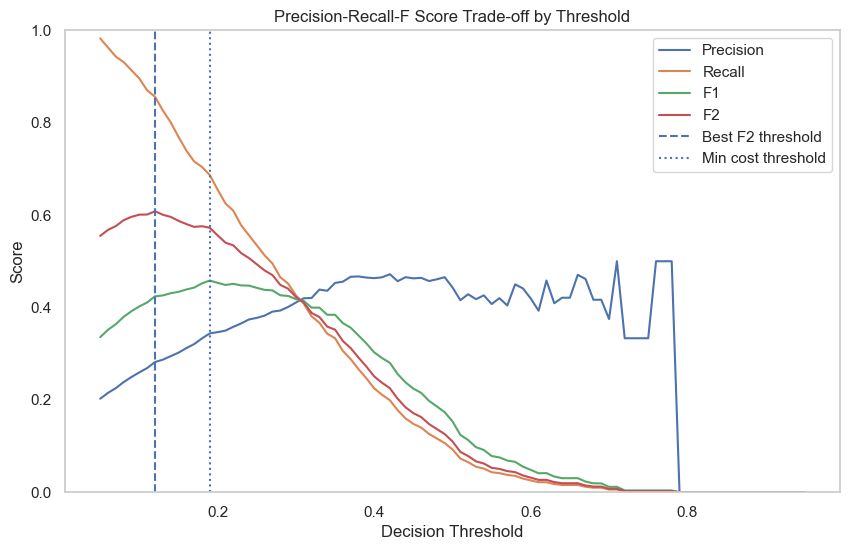

In [19]:
# plot threshold trade-offs
plt.figure(figsize=(10, 6))
plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1")
plt.plot(threshold_results["threshold"], threshold_results["f2"], label="F2")
plt.axvline(best_f2_threshold_row["threshold"], linestyle="--", label="Best F2 threshold")
plt.axvline(best_cost_threshold_row["threshold"], linestyle=":", label="Min cost threshold")
plt.title("Precision-Recall-F Score Trade-off by Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(False)
plt.show()

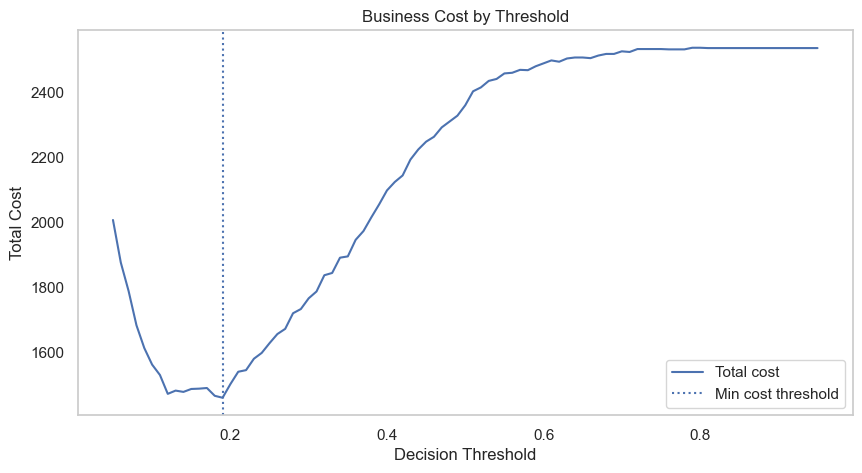

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_results["threshold"], threshold_results["total_cost"], label="Total cost")
plt.axvline(best_cost_threshold_row["threshold"], linestyle=":", label="Min cost threshold")
plt.title("Business Cost by Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Cost")
plt.legend()
plt.grid(False)
plt.show()

**Threshold tuning interpretation**

The F2-optimal threshold is **0.12**, which gives very high recall (**85.6%**) but also produces many false positives (**1,106** retained users incorrectly flagged as churned). 
> This is useful if the business objective is to capture as many churners as possible, but it may be too aggressive for a real retention campaign.

The minimum-cost threshold is **0.19**. Compared with the F2-optimal threshold, it reduces false positives from **1,106** to **664**, while recall decreases from **85.6%** to **68.6%** on the validation set. Under the assumed cost ratio, this threshold gives the lowest total cost.

> Therefore, the final threshold is selected based on minimum business cost rather than maximum recall. This directly addresses the trade-off between catching churners and avoiding excessive unnecessary interventions.

### 10.1. Final Threshold Selection

Based on the threshold tuning results, I will use the **minimum-cost threshold** as the final decision threshold.

Although the F2-optimal threshold captures more churned users, it also creates a much larger number of false positives. For a retention use case, this can lead to unnecessary interventions, wasted campaign resources, and poor user targeting.

Therefore, the final model uses the threshold that minimizes the assumed business cost. This choice reflects the main objective of the project: not simply maximizing recall, but building a churn risk model that balances churn detection with practical intervention cost.

In [21]:
# select final threshold based on business cost minimization
final_threshold = float(best_cost_threshold_row["threshold"])

print(f"Final selected threshold: {final_threshold:.2f}")

Final selected threshold: 0.19


## 11. Final Evaluation on Test Set

After selecting the final model, calibrating its probabilities, and choosing the decision threshold on the validation set, the final step is to evaluate performance on the unseen test set.

The test set has not been used for model selection, calibration, or threshold tuning. Therefore, it provides a more realistic estimate of how the final churn risk model may perform on new users.

In this step, I will apply the calibrated model and the selected threshold of **0.19** to the test set, then evaluate both ranking performance and classification performance using:

- Precision, Recall, F1-score, and F2-score
- ROC-AUC and PR-AUC
- Confusion matrix
- False positives and false negatives.

The goal is not only to check whether the model can identify churned users, but also to understand the trade-off between capturing churners and incorrectly flagging retained users.

In [22]:
# predict probabilities on the test set using calibrated model
y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= final_threshold).astype(int)

test_metrics = evaluate_binary_classifier(
    y_test,
    y_test_proba,
    threshold=final_threshold
)

test_metrics["model"] = candidate_model_name
test_metrics["threshold_source"] = "validation_min_cost"

print("Final test metrics:")
display(pd.DataFrame([test_metrics]))

Final test metrics:


,threshold,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,model,threshold_source
0,0.1900,0.6885,0.3140,0.6391,0.4211,0.5294,0.7415,0.3678,LogisticRegression_RobustCapped,validation_min_cost


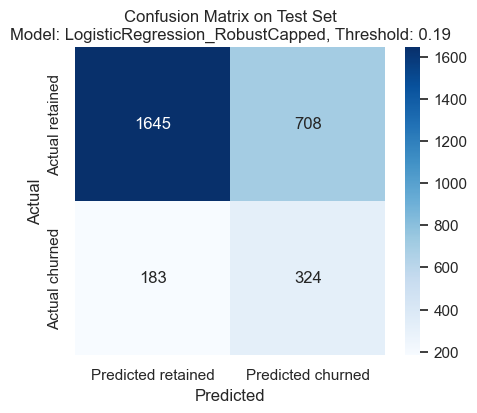

              precision    recall  f1-score   support

    retained       0.90      0.70      0.79      2353
     churned       0.31      0.64      0.42       507

    accuracy                           0.69      2860
   macro avg       0.61      0.67      0.60      2860
weighted avg       0.80      0.69      0.72      2860



In [23]:
# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted retained", "Predicted churned"],
    yticklabels=["Actual retained", "Actual churned"]
)
plt.title(f"Confusion Matrix on Test Set\nModel: {candidate_model_name}, Threshold: {final_threshold:.2f}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["retained", "churned"],
    zero_division=0
))

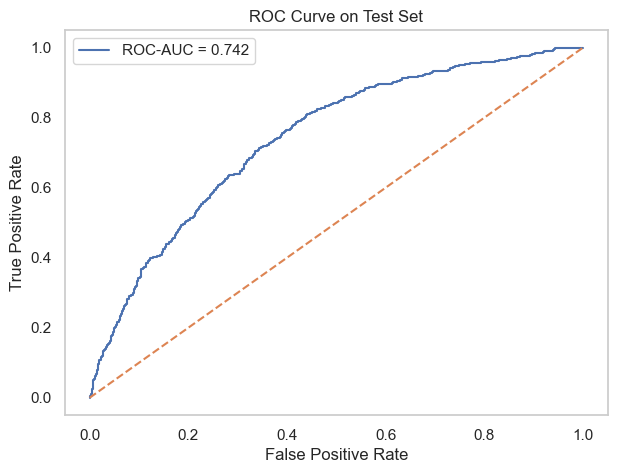

In [24]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_test_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve on Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(False)
plt.show()

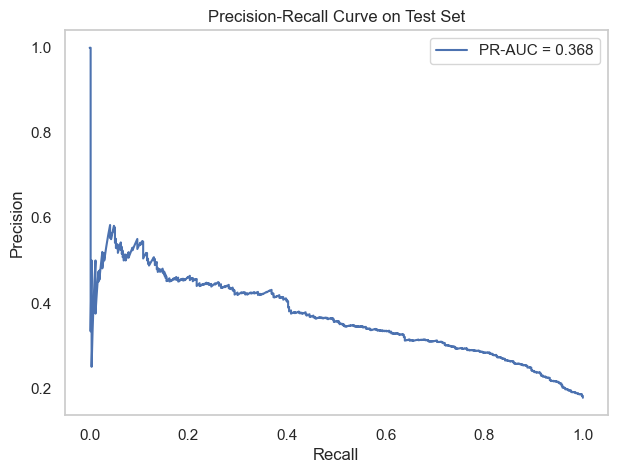

In [25]:
# Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {average_precision_score(y_test, y_test_proba):.3f}")
plt.title("Precision-Recall Curve on Test Set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(False)
plt.show()

**Final test result interpretation**

On the unseen test set, the final calibrated Logistic Regression model with threshold **0.19** achieves:

- Precision: **31.4%**
- Recall: **63.9%**
- F2-score: **52.9%**
- ROC-AUC: **0.742**
- PR-AUC: **0.368**

The model captures around two-thirds of actual churned users while avoiding the overly aggressive behavior of a recall-only model. Precision remains modest, which means some retained users are still incorrectly flagged as churned. However, this is expected in an imbalanced churn setting where the goal is early risk detection rather than perfect classification.

The result should be interpreted as a prioritization model: it helps identify a higher-risk group for retention actions, rather than making a definitive statement that every flagged user will churn.

## 12. Error Analysis: False Positives and False Negatives

Before moving to deeper model interpretation in Notebook 04, I will briefly inspect the errors.

This helps answer:

- What do false positives look like?
- What do false negatives look like?
- Is the model missing a specific type of churned user?
- Is the model over-targeting a specific type of retained user?

In [26]:
test_analysis = X_test.copy()
test_analysis["actual_churn"] = y_test.values
test_analysis["predicted_churn"] = y_test_pred
test_analysis["churn_probability"] = y_test_proba

def assign_error_type(row):
    if row["actual_churn"] == 1 and row["predicted_churn"] == 1:
        return "True Positive"
    elif row["actual_churn"] == 0 and row["predicted_churn"] == 0:
        return "True Negative"
    elif row["actual_churn"] == 0 and row["predicted_churn"] == 1:
        return "False Positive"
    else:
        return "False Negative"

test_analysis["error_type"] = test_analysis.apply(assign_error_type, axis=1)

error_counts = (
    test_analysis["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="count")
)

display(error_counts)

,error_type,count
0,True Negative,1645
1,False Positive,708
2,True Positive,324
3,False Negative,183


In [27]:
# add engineered features for error analysis
test_analysis_fe = add_waze_features(test_analysis.drop(columns=[
    "actual_churn", "predicted_churn", "churn_probability", "error_type"
]))

test_analysis_fe["actual_churn"] = test_analysis["actual_churn"].values
test_analysis_fe["predicted_churn"] = test_analysis["predicted_churn"].values
test_analysis_fe["churn_probability"] = test_analysis["churn_probability"].values
test_analysis_fe["error_type"] = test_analysis["error_type"].values

key_behavior_features = [
    "sessions",
    "drives",
    "activity_days",
    "driving_days",
    "n_days_after_onboarding",
    "km_per_driving_day",
    "drives_per_activity_day",
    "drives_per_driving_day",
    "total_favorite_navigations",
    "percent_sessions_in_last_month",
    "churn_probability"
]

error_profile = (
    test_analysis_fe
    .groupby("error_type")[key_behavior_features]
    .median()
    .round(3)
)

display(error_profile)

,sessions,drives,activity_days,driving_days,n_days_after_onboarding,km_per_driving_day,drives_per_activity_day,drives_per_driving_day,total_favorite_navigations,percent_sessions_in_last_month,churn_probability
error_type,,,,,,,,,,,
False Negative,56.0000,50.0000,17.0000,13.0000,1576.0000,271.3560,3.2000,4.2110,99.0000,0.4890,0.1240
False Positive,58.0000,49.0000,6.0000,4.0000,1389.5000,603.9800,7.5000,7.1060,114.0000,0.4200,0.2880
True Negative,55.0000,47.0000,22.0000,17.0000,2099.0000,222.6390,2.3000,2.8670,96.0000,0.4310,0.0790
True Positive,58.0000,48.5000,4.0000,3.0000,1200.5000,659.8340,9.5000,7.4380,137.5000,0.4380,0.3440


**Error analysis interpretation**

The error analysis shows that false positives and true positives have similar behavioral profiles. Both groups have relatively low `activity_days` and `driving_days`, but high daily driving intensity. This means the model tends to flag users who concentrate their usage into fewer days, which is consistent with the EDA insight that low consistency is associated with churn.

False positives are retained users, but their behavior looks risky: they have low activity frequency and high `km_per_driving_day`. These users may not be true model failures from a business perspective. They could represent users who appear behaviorally at risk but still remained active during the observed label window.

False negatives are different. They have higher median `activity_days` and `driving_days`, making them look more similar to retained users. This suggests that the model is more likely to miss churned users who appear reasonably active based on the available features.

This limitation indicates that some churn behavior may not be fully explained by the current snapshot features. Additional temporal signals, such as recent decline in activity, app experience issues, route quality, or notification engagement, could help reduce false negatives in future work.

## 13. Save Final Model Artifacts

After final test evaluation, I will save the key artifacts needed to reproduce the model outputs and continue the analysis in the next notebook.

The saved artifacts include:

- The final calibrated churn model;
- The selected decision threshold;
- Model metadata and performance summary;
- Input feature columns used by the model;
- Cross-validation results;
- Validation results;
- Threshold tuning results;
- Final test predictions with churn probabilities and predicted labels.

Saving these artifacts ensures that Notebook 04 can focus on model interpretation and business translation without retraining the model. In particular, the saved prediction outputs will be used for churn risk tiering, high-risk user profiling, error analysis, and business recommendations.

In [28]:
# create output directories
os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# save final calibrated model
model_path = "../models/waze_churn_calibrated_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(calibrated_model, f)

# save selected threshold and metadata
metadata = {
    "candidate_model_name": candidate_model_name,
    "final_threshold": final_threshold,
    "threshold_selection": "minimum validation cost",
    "false_negative_cost": 5,
    "false_positive_cost": 1,
    "test_metrics": test_metrics
}

metadata_path = "../models/waze_churn_model_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

# save input feature columns
feature_columns_path = "../models/waze_churn_input_features.pkl"
with open(feature_columns_path, "wb") as f:
    pickle.dump(list(X.columns), f)

# save results tables
cv_results_df.to_csv("../models/model_cv_results.csv", index=False)
validation_results_df.to_csv("../models/model_validation_results.csv", index=False)
threshold_results.to_csv("../models/threshold_tuning_results.csv", index=False)

# save test predictions for Notebook 04
test_predictions = test_analysis_fe.copy()
test_predictions.to_csv("../data/processed/waze_test_predictions.csv", index=False)

print("Saved artifacts:")
print(f"- {model_path}")
print(f"- {metadata_path}")
print(f"- {feature_columns_path}")
print("- ../models/model_cv_results.csv")
print("- ../models/model_validation_results.csv")
print("- ../models/threshold_tuning_results.csv")
print("- ../data/processed/waze_test_predictions.csv")

Saved artifacts:
- ../models/waze_churn_calibrated_model.pkl
- ../models/waze_churn_model_metadata.json
- ../models/waze_churn_input_features.pkl
- ../models/model_cv_results.csv
- ../models/model_validation_results.csv
- ../models/threshold_tuning_results.csv
- ../data/processed/waze_test_predictions.csv


## 14. Modeling Limitations

The final model should be interpreted as a **churn risk prioritization model**, not as a perfect churn classifier.

Several limitations remain:

- The dataset is a static user-level snapshot. It does not contain detailed time-series activity logs, so the model cannot directly capture recent declines in user behavior.
- Precision remains modest, meaning some retained users are still incorrectly flagged as churned. Therefore, retention actions should be prioritized by risk tier and campaign capacity rather than applied blindly to every predicted churn user.
- The validation set is used for candidate model selection, probability calibration, and threshold tuning. This is acceptable for this project, but in a production setting these steps should ideally be separated further or handled with nested cross-validation.
- The cost ratio used in threshold tuning is an assumption. A real deployment should estimate false-positive and false-negative costs using campaign cost, customer lifetime value, and expected intervention effectiveness.
- The model only uses available behavioral and device-level features. It does not include potentially important product signals such as app crashes, route quality, notification engagement, user satisfaction, support tickets, or temporal activity trends.

These limitations suggest that the model should be used to **prioritize users for further action**, not to make fully automated retention decisions.

## 15. Summary & Next Steps

In this notebook, I built and evaluated a churn prediction model using a business-aware modeling framework.

The main steps included:

- Recreating engagement-based features from the cleaned dataset;
- Splitting the data into training, validation, and test sets;
- Comparing baseline and machine learning models, including Dummy Classifier, Logistic Regression, Decision Tree, Random Forest, XGBoost and SVM;
- Evaluating models using Precision, Recall, F1-score, F2-score, ROC-AUC, and PR-AUC instead of accuracy alone;
- Selecting `LogisticRegression_RobustCapped` as the final candidate model based on validation performance;
- Calibrating predicted probabilities to make churn risk scores more reliable;
- Tuning the decision threshold using both F2-score and cost-sensitive evaluation;
- Selecting the minimum-cost threshold of **0.19** as the final decision threshold;
- Evaluating the final calibrated model on the unseen test set;
- Saving the final model artifacts and prediction outputs for the next notebook.

The final test results show that the model can capture a meaningful share of churned users while keeping false positives more controlled than a recall-only approach. However, the model should be interpreted as a **risk scoring and prioritization system** rather than a perfect binary classifier.

The next notebook will use the saved churn probabilities and predictions to build business-facing outputs, including:

- Churn risk tiers;
- High-risk user profiling;
- Model interpretation;
- Error analysis;
- Retention recommendation strategies.